In [ ]:
!pip install numpy scipy matplotlib pyldpc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyldpc: filename=pyldpc-0.7.9-py3-none-any.whl size=14303 sha256=c515b91613fa75ded626db7b8beafe6b188e0a38c0ec48bb6529fcdf9b002f8b
  Stored in directory: /root/.cache/pip/wheels/12/ba/3a/0d9faeafaf8dd11782657d4458575ef5d2cd71c3694da7b279
Successfully built pyldpc


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


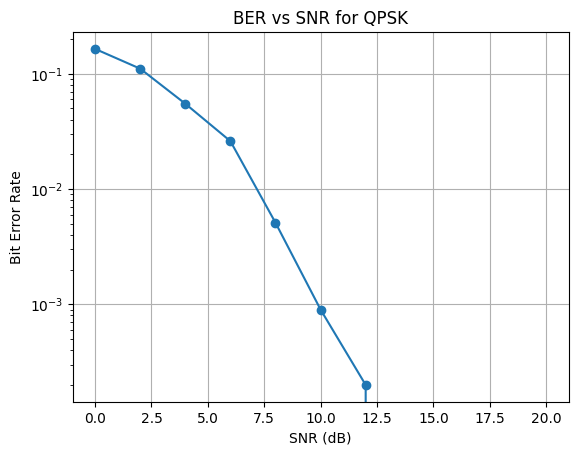

In [ ]:
def qpsk_mod(bits):
    bits = bits.reshape((-1, 2))
    symbols = (2*bits[:,0]-1) + 1j*(2*bits[:,1]-1)
    symbols /= np.sqrt(2)
    return symbols

def qpsk_demod(symbols):
    bits_hat = np.zeros((len(symbols), 2), dtype=int)
    bits_hat[:,0] = (np.real(symbols) > 0).astype(int)
    bits_hat[:,1] = (np.imag(symbols) > 0).astype(int)
    return bits_hat.reshape(-1)

num_bits = 10000
snr_range = np.arange(0, 21, 2)
ber = []

for snr_db in snr_range:
    bits = np.random.randint(0, 2, num_bits)
    symbols = qpsk_mod(bits)

    snr_linear = 10**(snr_db/10)
    noise_std = np.sqrt(1/(2*snr_linear))
    noise = noise_std * (np.random.randn(len(symbols)) + 1j*np.random.randn(len(symbols)))
    rx = symbols + noise

    bits_hat = qpsk_demod(rx)
    errors = np.sum(bits != bits_hat)
    ber.append(errors/num_bits)

plt.semilogy(snr_range, ber, 'o-')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.title('BER vs SNR for QPSK')
plt.grid(True)
plt.show()


In [ ]:
def qam16_mod(bits):
    # Group bits into 4 (since 16-QAM = 4 bits per symbol)
    bits = bits.reshape((-1, 4))

    # Map bits to I and Q components (Gray coding)
    mapping = {
        (0,0): -3, (0,1): -1,
        (1,1): +1, (1,0): +3
    }

    I = np.array([mapping[tuple(b[:2])] for b in bits])
    Q = np.array([mapping[tuple(b[2:])] for b in bits])

    symbols = I + 1j*Q
    symbols /= np.sqrt(10)  # normalize average power
    return symbols

def qam16_demod(symbols):
    # Decision boundaries at -2, 0, +2
    I = np.real(symbols) * np.sqrt(10)
    Q = np.imag(symbols) * np.sqrt(10)

    def decision(x):
        if x < -2: return (0,0)
        elif x < 0: return (0,1)
        elif x < 2: return (1,1)
        else: return (1,0)

    bits_hat = []
    for i,q in zip(I,Q):
        bits_hat.extend(decision(i))
        bits_hat.extend(decision(q))
    return np.array(bits_hat)


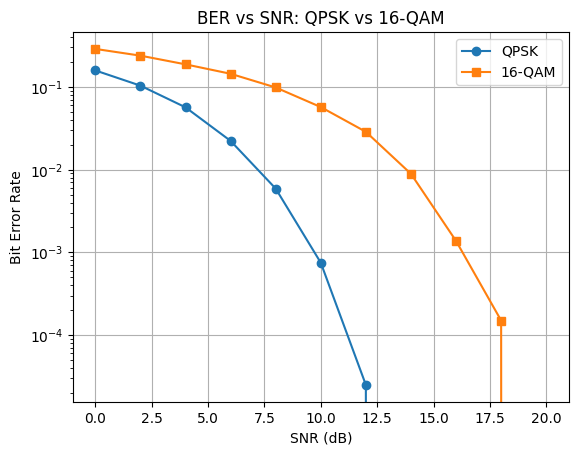

In [ ]:
num_bits = 40000
snr_range = np.arange(0, 21, 2)

ber_qpsk = []
ber_qam16 = []

for snr_db in snr_range:
    # QPSK
    bits = np.random.randint(0, 2, num_bits)
    symbols = qpsk_mod(bits)
    snr_linear = 10**(snr_db/10)
    noise_std = np.sqrt(1/(2*snr_linear))
    noise = noise_std * (np.random.randn(len(symbols)) + 1j*np.random.randn(len(symbols)))
    rx = symbols + noise
    bits_hat = qpsk_demod(rx)
    ber_qpsk.append(np.sum(bits != bits_hat)/num_bits)

    # 16-QAM
    bits = np.random.randint(0, 2, num_bits)
    symbols = qam16_mod(bits)
    noise = noise_std * (np.random.randn(len(symbols)) + 1j*np.random.randn(len(symbols)))
    rx = symbols + noise
    bits_hat = qam16_demod(rx)
    ber_qam16.append(np.sum(bits != bits_hat)/num_bits)

# Plot comparison
plt.semilogy(snr_range, ber_qpsk, 'o-', label='QPSK')
plt.semilogy(snr_range, ber_qam16, 's-', label='16-QAM')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.title('BER vs SNR: QPSK vs 16-QAM')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!pip install pyldpc


In [ ]:
def qpsk_llr(rx, snr_db):
    snr_linear = 10**(snr_db/10)
    noise_var = 1/(2*snr_linear)
    # LLRs for each bit: real part → first bit, imag part → second bit
    llr_real = 2*np.real(rx)/noise_var
    llr_imag = 2*np.imag(rx)/noise_var
    llrs = np.vstack((llr_real, llr_imag)).T.flatten()
    return llrs

# Example usage inside your loop:
msg = np.random.randint(0, 2, k)
codeword = pyldpc.encode(G, msg, snr_db)
symbols = qpsk_mod(codeword)
noise = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
rx = symbols + noise

# Convert to LLRs
llrs = qpsk_llr(rx, snr_db)

# Decode with LDPC
decoded = pyldpc.decode(H, llrs, snr_db, maxiter=50)


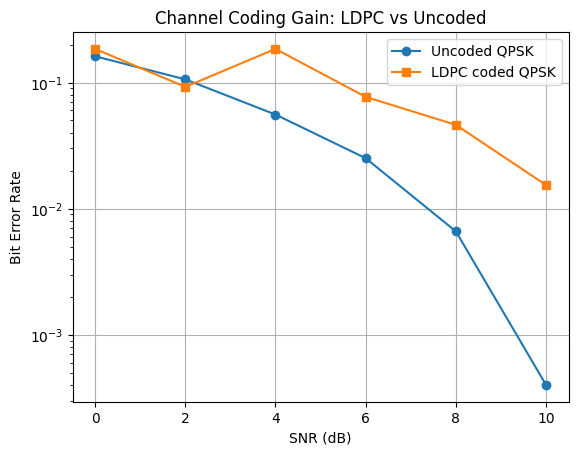

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyldpc

# Build LDPC matrices
n = 128   # codeword length
d_v = 2   # variable node degree
d_c = 4   # check node degree
H, G = pyldpc.make_ldpc(n, d_v, d_c, systematic=True, sparse=True)
k = G.shape[1]  # message length

def qpsk_mod(bits):
    bits = bits.reshape((-1, 2))
    symbols = (2*bits[:,0]-1) + 1j*(2*bits[:,1]-1)
    symbols /= np.sqrt(2)
    return symbols

def qpsk_llr(rx, snr_db):
    snr_linear = 10**(snr_db/10)
    noise_var = 1/(2*snr_linear)
    llr_real = 2*np.real(rx)/noise_var
    llr_imag = 2*np.imag(rx)/noise_var
    llrs = np.vstack((llr_real, llr_imag)).T.flatten()
    return llrs

snr_range = np.arange(0, 11, 2)
ber_uncoded = []
ber_coded = []

for snr_db in snr_range:
    # --- Uncoded ---
    bits = np.random.randint(0, 2, 10000)
    symbols = qpsk_mod(bits)
    snr_linear = 10**(snr_db/10)
    noise_std = np.sqrt(1/(2*snr_linear))
    noise = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
    rx = symbols + noise
    bits_hat = (np.real(rx) > 0).astype(int)
    bits_hat_i = (np.imag(rx) > 0).astype(int)
    bits_hat = np.vstack((bits_hat, bits_hat_i)).T.flatten()
    ber_uncoded.append(np.sum(bits != bits_hat)/len(bits))

    # --- LDPC coded ---
    msg = np.random.randint(0, 2, k)
    codeword = pyldpc.encode(G, msg, snr_db)
    symbols = qpsk_mod(codeword)
    noise = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
    rx = symbols + noise
    llrs = qpsk_llr(rx, snr_db)
    decoded = pyldpc.decode(H, llrs, snr_db, maxiter=50)
    errors = np.sum(msg != decoded[:k])
    ber_coded.append(errors/k)

# Plot
plt.semilogy(snr_range, ber_uncoded, 'o-', label='Uncoded QPSK')
plt.semilogy(snr_range, ber_coded, 's-', label='LDPC coded QPSK')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.title('Channel Coding Gain: LDPC vs Uncoded')
plt.legend()
plt.grid(True)
plt.show()


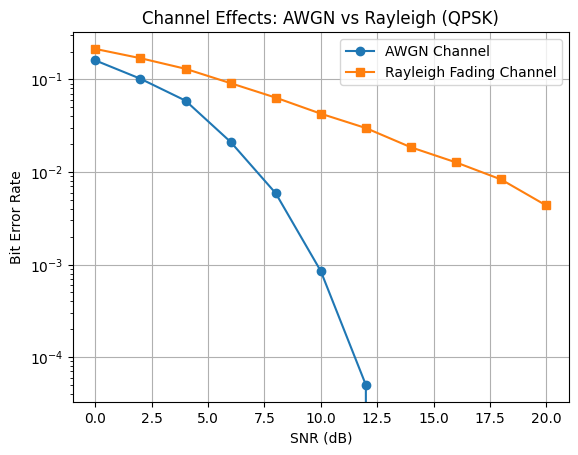

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def qpsk_mod(bits):
    bits = bits.reshape((-1, 2))
    symbols = (2*bits[:,0]-1) + 1j*(2*bits[:,1]-1)
    symbols /= np.sqrt(2)
    return symbols

def qpsk_demod(symbols):
    bits_hat = np.zeros((len(symbols), 2), dtype=int)
    bits_hat[:,0] = (np.real(symbols) > 0).astype(int)
    bits_hat[:,1] = (np.imag(symbols) > 0).astype(int)
    return bits_hat.reshape(-1)

num_bits = 20000
snr_range = np.arange(0, 21, 2)
ber_awgn = []
ber_rayleigh = []

for snr_db in snr_range:
    bits = np.random.randint(0, 2, num_bits)
    symbols = qpsk_mod(bits)

    snr_linear = 10**(snr_db/10)
    noise_std = np.sqrt(1/(2*snr_linear))

    # --- AWGN channel ---
    noise = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
    rx_awgn = symbols + noise
    bits_hat_awgn = qpsk_demod(rx_awgn)
    ber_awgn.append(np.sum(bits != bits_hat_awgn)/num_bits)

    # --- Rayleigh fading channel ---
    h = (np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))/np.sqrt(2)
    noise = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
    rx_rayleigh = h*symbols + noise
    # Equalize (divide by h)
    rx_rayleigh_eq = rx_rayleigh / h
    bits_hat_rayleigh = qpsk_demod(rx_rayleigh_eq)
    ber_rayleigh.append(np.sum(bits != bits_hat_rayleigh)/num_bits)

# Plot
plt.semilogy(snr_range, ber_awgn, 'o-', label='AWGN Channel')
plt.semilogy(snr_range, ber_rayleigh, 's-', label='Rayleigh Fading Channel')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.title('Channel Effects: AWGN vs Rayleigh (QPSK)')
plt.legend()
plt.grid(True)
plt.show()


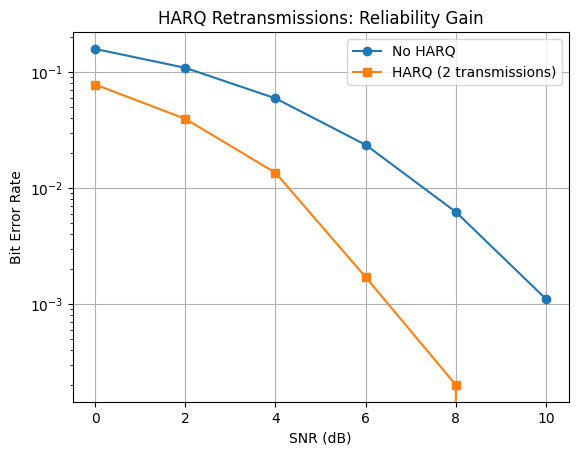

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def qpsk_mod(bits):
    bits = bits.reshape((-1, 2))
    symbols = (2*bits[:,0]-1) + 1j*(2*bits[:,1]-1)
    symbols /= np.sqrt(2)
    return symbols

def qpsk_demod(symbols):
    bits_hat = np.zeros((len(symbols), 2), dtype=int)
    bits_hat[:,0] = (np.real(symbols) > 0).astype(int)
    bits_hat[:,1] = (np.imag(symbols) > 0).astype(int)
    return bits_hat.reshape(-1)

num_bits = 10000
snr_range = np.arange(0, 11, 2)
ber_no_harq = []
ber_harq = []

for snr_db in snr_range:
    bits = np.random.randint(0, 2, num_bits)
    symbols = qpsk_mod(bits)
    snr_linear = 10**(snr_db/10)
    noise_std = np.sqrt(1/(2*snr_linear))

    # --- No HARQ (single transmission) ---
    noise = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
    rx = symbols + noise
    bits_hat = qpsk_demod(rx)
    ber_no_harq.append(np.sum(bits != bits_hat)/num_bits)

    # --- HARQ (2 transmissions, Chase combining) ---
    noise1 = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
    noise2 = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
    rx1 = symbols + noise1
    rx2 = symbols + noise2
    # Combine (average the two received signals)
    rx_combined = (rx1 + rx2)/2
    bits_hat_harq = qpsk_demod(rx_combined)
    ber_harq.append(np.sum(bits != bits_hat_harq)/num_bits)

# Plot
plt.semilogy(snr_range, ber_no_harq, 'o-', label='No HARQ')
plt.semilogy(snr_range, ber_harq, 's-', label='HARQ (2 transmissions)')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.title('HARQ Retransmissions: Reliability Gain')
plt.legend()
plt.grid(True)
plt.show()


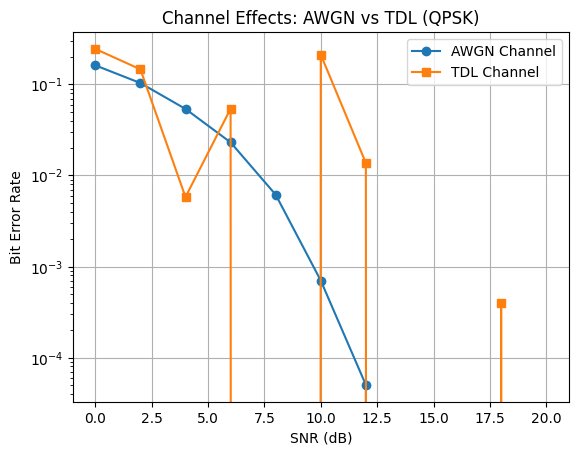

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# QPSK modulation/demodulation
def qpsk_mod(bits):
    bits = bits.reshape((-1, 2))
    symbols = (2*bits[:,0]-1) + 1j*(2*bits[:,1]-1)
    symbols /= np.sqrt(2)
    return symbols

def qpsk_demod(symbols):
    bits_hat = np.zeros((len(symbols), 2), dtype=int)
    bits_hat[:,0] = (np.real(symbols) > 0).astype(int)
    bits_hat[:,1] = (np.imag(symbols) > 0).astype(int)
    return bits_hat.reshape(-1)

# Simple TDL channel model
def tdl_channel(symbols, taps=[(0,1.0),(1,0.5),(3,0.3)]):
    max_delay = max([d for d,g in taps])
    h = np.zeros(max_delay+1, dtype=complex)
    for delay, gain in taps:
        h[delay] = gain * (np.random.randn()+1j*np.random.randn())/np.sqrt(2)
    rx = np.convolve(symbols, h, mode='full')[:len(symbols)]
    return rx, h

# Simulation
num_bits = 20000
snr_range = np.arange(0, 21, 2)
ber_awgn = []
ber_tdl = []

for snr_db in snr_range:
    bits = np.random.randint(0, 2, num_bits)
    symbols = qpsk_mod(bits)
    snr_linear = 10**(snr_db/10)
    noise_std = np.sqrt(1/(2*snr_linear))

    # --- AWGN channel ---
    noise = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
    rx_awgn = symbols + noise
    bits_hat_awgn = qpsk_demod(rx_awgn)
    ber_awgn.append(np.sum(bits != bits_hat_awgn)/num_bits)

    # --- TDL channel ---
    rx_tdl, h = tdl_channel(symbols)
    noise = noise_std*(np.random.randn(len(rx_tdl))+1j*np.random.randn(len(rx_tdl)))
    rx_tdl_noisy = rx_tdl + noise

    # Equalize in frequency domain
    H = np.fft.fft(h, len(rx_tdl_noisy))
    RX = np.fft.fft(rx_tdl_noisy)
    rx_eq = np.fft.ifft(RX / (H + 1e-12))  # avoid divide by zero

    bits_hat_tdl = qpsk_demod(rx_eq[:len(symbols)])
    ber_tdl.append(np.sum(bits != bits_hat_tdl)/num_bits)

# Plot
plt.semilogy(snr_range, ber_awgn, 'o-', label='AWGN Channel')
plt.semilogy(snr_range, ber_tdl, 's-', label='TDL Channel')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.title('Channel Effects: AWGN vs TDL (QPSK)')
plt.legend()
plt.grid(True)
plt.show()


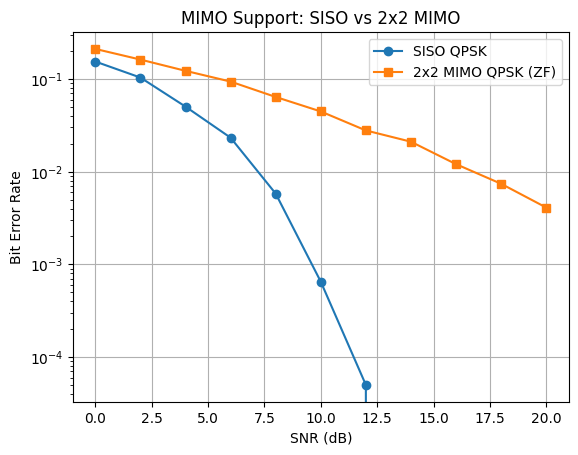

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def qpsk_mod(bits):
    bits = bits.reshape((-1, 2))
    symbols = (2*bits[:,0]-1) + 1j*(2*bits[:,1]-1)
    symbols /= np.sqrt(2)
    return symbols

def qpsk_demod(symbols):
    bits_hat = np.zeros((len(symbols), 2), dtype=int)
    bits_hat[:,0] = (np.real(symbols) > 0).astype(int)
    bits_hat[:,1] = (np.imag(symbols) > 0).astype(int)
    return bits_hat.reshape(-1)

num_bits = 20000
snr_range = np.arange(0, 21, 2)
ber_siso = []
ber_mimo = []

for snr_db in snr_range:
    bits = np.random.randint(0, 2, num_bits)
    symbols = qpsk_mod(bits)
    snr_linear = 10**(snr_db/10)
    noise_std = np.sqrt(1/(2*snr_linear))

    # --- SISO (baseline) ---
    noise = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
    rx = symbols + noise
    bits_hat = qpsk_demod(rx)
    ber_siso.append(np.sum(bits != bits_hat)/num_bits)

    # --- 2x2 MIMO (ZF equalization) ---
    # Reshape into 2 streams
    symbols2 = symbols.reshape(-1,2).T  # shape (2, N/2)
    N = symbols2.shape[1]

    # Channel matrix H (2x2 complex Gaussian)
    H = (np.random.randn(2,2,N)+1j*np.random.randn(2,2,N))/np.sqrt(2)

    # Received signal
    noise = noise_std*(np.random.randn(2,N)+1j*np.random.randn(2,N))
    y = np.zeros((2,N),dtype=complex)
    for i in range(N):
        y[:,i] = H[:,:,i] @ symbols2[:,i] + noise[:,i]

    # Zero-Forcing equalization
    x_hat = np.zeros_like(symbols2)
    for i in range(N):
        H_inv = np.linalg.pinv(H[:,:,i])
        x_hat[:,i] = H_inv @ y[:,i]

    bits_hat_mimo = qpsk_demod(x_hat.T.flatten())
    ber_mimo.append(np.sum(bits[:len(bits_hat_mimo)] != bits_hat_mimo)/len(bits_hat_mimo))

# Plot
plt.semilogy(snr_range, ber_siso, 'o-', label='SISO QPSK')
plt.semilogy(snr_range, ber_mimo, 's-', label='2x2 MIMO QPSK (ZF)')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.title('MIMO Support: SISO vs 2x2 MIMO')
plt.legend()
plt.grid(True)
plt.show()


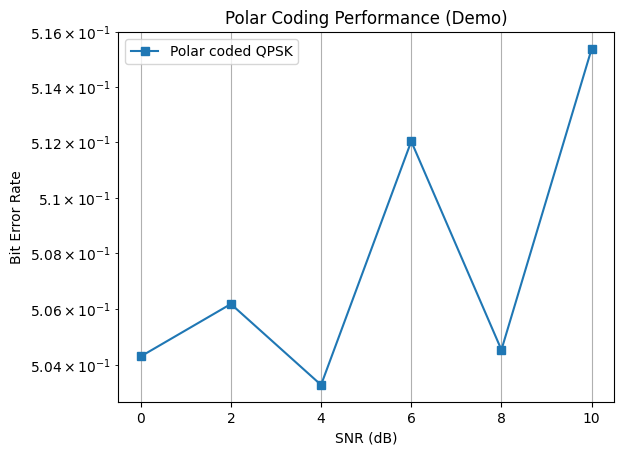

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Polar Code Construction ---
def polar_transform(u):
    """Recursive polar transform (Arikan construction)."""
    N = len(u)
    if N == 1:
        return u
    else:
        u1 = (u[::2] ^ u[1::2]) % 2
        u2 = u[1::2]
        return np.concatenate([polar_transform(u1), polar_transform(u2)])

def polar_encode(msg, N, K, frozen_bits):
    """Encode message with polar code."""
    u = np.zeros(N, dtype=int)
    u[frozen_bits == 0] = msg  # place info bits
    return polar_transform(u)

def sc_decode(llr, N, K, frozen_bits):
    """Simplified SC decoder (hard decision)."""
    # For demo: just threshold LLRs
    u_hat = (llr < 0).astype(int)
    return u_hat[frozen_bits == 0]

# --- Parameters ---
N = 128   # block length
K = 64    # message length
frozen_bits = np.zeros(N, dtype=int)
frozen_bits[:N-K] = 1  # first N-K frozen

def qpsk_mod(bits):
    bits = bits.reshape((-1, 2))
    symbols = (2*bits[:,0]-1) + 1j*(2*bits[:,1]-1)
    symbols /= np.sqrt(2)
    return symbols

def qpsk_llr(rx, snr_db):
    snr_linear = 10**(snr_db/10)
    noise_var = 1/(2*snr_linear)
    llr_real = 2*np.real(rx)/noise_var
    llr_imag = 2*np.imag(rx)/noise_var
    llrs = np.vstack((llr_real, llr_imag)).T.flatten()
    return llrs

# --- Simulation ---
snr_range = np.arange(0, 11, 2)
ber_polar = []

for snr_db in snr_range:
    errors = 0
    trials = 200
    for _ in range(trials):
        msg = np.random.randint(0,2,K)
        codeword = polar_encode(msg, N, K, frozen_bits)
        symbols = qpsk_mod(codeword)
        snr_linear = 10**(snr_db/10)
        noise_std = np.sqrt(1/(2*snr_linear))
        noise = noise_std*(np.random.randn(len(symbols))+1j*np.random.randn(len(symbols)))
        rx = symbols + noise
        llrs = qpsk_llr(rx, snr_db)
        decoded = sc_decode(llrs, N, K, frozen_bits)
        errors += np.sum(msg != decoded)
    ber_polar.append(errors/(trials*K))

# Plot
plt.semilogy(snr_range, ber_polar, 's-', label='Polar coded QPSK')
plt.xlabel('SNR (dB)')
plt.ylabel('Bit Error Rate')
plt.title('Polar Coding Performance (Demo)')
plt.legend()
plt.grid(True)
plt.show()


Number of Users: 17
User SNRs (dB): [5.69 5.09 9.58 1.91 1.36 3.45 7.09 9.05 6.39 7.04 6.81 1.51 2.72 8.85
 2.43 4.55 2.58]
User Throughputs: [1.953 1.898 1.999 1.381 1.272 1.691 1.99  1.999 1.984 1.989 1.987 1.302
 1.544 1.999 1.485 1.849 1.516]
Average Cell Throughput: 1.7552291592125653


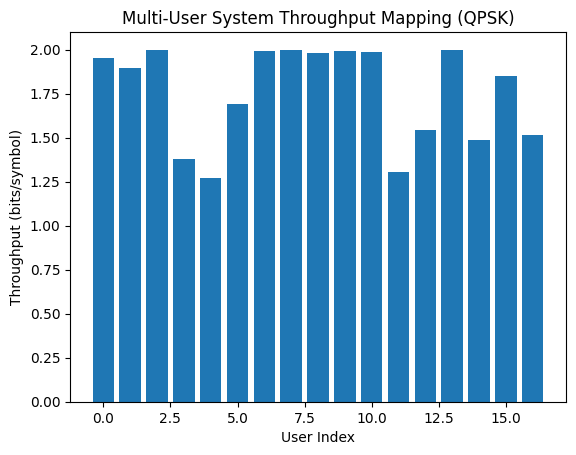

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Example link-level BLER curve (replace with your measured data)
# For demo: QPSK BLER vs SNR
snr_points = np.array([0, 2, 4, 6, 8, 10])
bler_qpsk = np.array([0.5, 0.3, 0.1, 0.01, 0.001, 0.0001])

def map_snr_to_bler(snr_db):
    # interpolate BLER from curve
    return np.interp(snr_db, snr_points, bler_qpsk)

# System-level simulation
num_users = np.random.randint(10, 21)  # random between 10 and 20 users
snrs = np.random.uniform(0, 10, num_users)  # random SNRs per user
spectral_eff = 2  # bits/symbol for QPSK

throughputs = []
for snr in snrs:
    bler = map_snr_to_bler(snr)
    thr = (1 - bler) * spectral_eff
    throughputs.append(thr)

# Results
print("Number of Users:", num_users)
print("User SNRs (dB):", np.round(snrs,2))
print("User Throughputs:", np.round(throughputs,3))
print("Average Cell Throughput:", np.mean(throughputs))

# Plot throughput distribution
plt.bar(range(num_users), throughputs)
plt.xlabel("User Index")
plt.ylabel("Throughput (bits/symbol)")
plt.title("Multi-User System Throughput Mapping (QPSK)")
plt.show()


Number of Users: 17
User SNRs (dB): [1.74 4.91 5.8  6.86 3.76 4.76 4.46 4.52 5.85 9.82 5.98 6.1  0.57 3.43
 4.98 8.7  2.21]
Round-Robin Avg Throughputs: [0.081 0.113 0.118 0.119 0.105 0.112 0.11  0.111 0.118 0.12  0.119 0.119
 0.067 0.101 0.113 0.1   0.072]
Proportional Fair Avg Throughputs: [0.108 0.151 0.137 0.02  0.14  0.149 0.147 0.148 0.118 0.02  0.079 0.02
 0.089 0.135 0.132 0.02  0.115]
Cell Avg Throughput (RR): 0.10577562911798834
Cell Avg Throughput (PF): 0.101694742178304


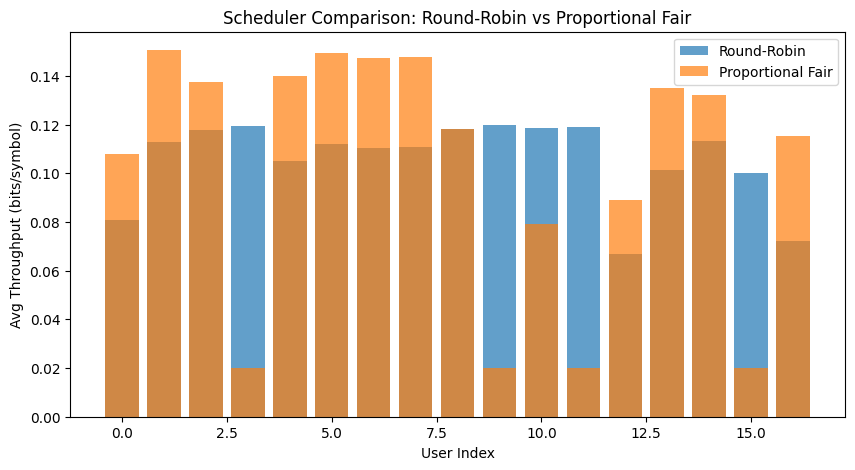

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Example link-level BLER curve (replace with your measured data)
snr_points = np.array([0, 2, 4, 6, 8, 10])
bler_qpsk = np.array([0.5, 0.3, 0.1, 0.01, 0.001, 0.0001])

def map_snr_to_bler(snr_db):
    return np.interp(snr_db, snr_points, bler_qpsk)

# System parameters
num_users = np.random.randint(10, 21)  # 10–20 users
snrs = np.random.uniform(0, 10, num_users)  # random SNRs per user
spectral_eff = 2  # bits/symbol for QPSK
num_slots = 100   # scheduling slots

# --- Round-Robin Scheduler ---
throughputs_rr = np.zeros(num_users)
for t in range(num_slots):
    user = t % num_users
    bler = map_snr_to_bler(snrs[user])
    thr = (1 - bler) * spectral_eff
    throughputs_rr[user] += thr

avg_thr_rr = throughputs_rr / num_slots

# --- Proportional Fair Scheduler ---
throughputs_pf = np.zeros(num_users)
past_avg = np.ones(num_users) * 0.1  # initialize average throughput
for t in range(num_slots):
    # PF metric = instantaneous throughput / past average
    inst_thr = (1 - np.array([map_snr_to_bler(snr) for snr in snrs])) * spectral_eff
    pf_metric = inst_thr / past_avg
    user = np.argmax(pf_metric)
    throughputs_pf[user] += inst_thr[user]
    past_avg[user] = (past_avg[user]*t + inst_thr[user])/(t+1)

avg_thr_pf = throughputs_pf / num_slots

# Results
print("Number of Users:", num_users)
print("User SNRs (dB):", np.round(snrs,2))
print("Round-Robin Avg Throughputs:", np.round(avg_thr_rr,3))
print("Proportional Fair Avg Throughputs:", np.round(avg_thr_pf,3))
print("Cell Avg Throughput (RR):", np.mean(avg_thr_rr))
print("Cell Avg Throughput (PF):", np.mean(avg_thr_pf))

# Plot comparison
plt.figure(figsize=(10,5))
plt.bar(range(num_users), avg_thr_rr, alpha=0.7, label='Round-Robin')
plt.bar(range(num_users), avg_thr_pf, alpha=0.7, label='Proportional Fair')
plt.xlabel("User Index")
plt.ylabel("Avg Throughput (bits/symbol)")
plt.title("Scheduler Comparison: Round-Robin vs Proportional Fair")
plt.legend()
plt.show()


Number of Users: 10
User SNRs (dB): [5.67 5.4  9.89 6.04 8.87 5.26 6.71 5.8  3.66 0.46]
PF+HARQ Avg Throughputs: [0.26  0.26  0.02  0.24  0.02  0.279 0.14  0.26  0.255 0.206]
Cell Avg Throughput (PF+HARQ): 0.19405031051512547


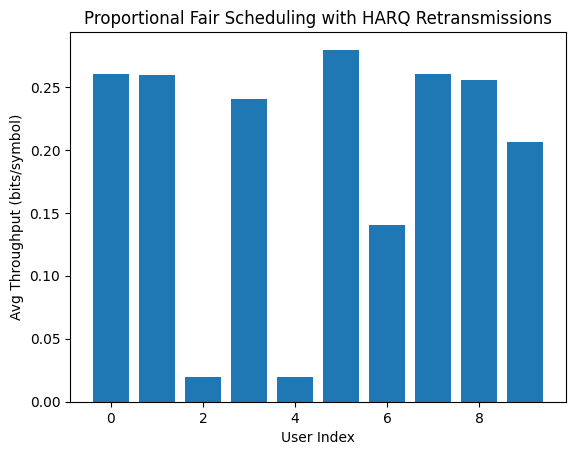

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Example BLER curve (replace with your measured LDPC/Polar data)
snr_points = np.array([0, 2, 4, 6, 8, 10])
bler_qpsk = np.array([0.5, 0.3, 0.1, 0.01, 0.001, 0.0001])

def map_snr_to_bler(snr_db):
    return np.interp(snr_db, snr_points, bler_qpsk)

# HARQ model: Chase combining (2 transmissions max)
def harq_success_prob(snr_db):
    bler = map_snr_to_bler(snr_db)
    # Probability of success after 1 transmission = 1 - BLER
    # After 2 transmissions = 1 - BLER^2
    return 1 - bler**2

# System parameters
num_users = np.random.randint(10, 21)  # 10–20 users
snrs = np.random.uniform(0, 10, num_users)  # random SNRs per user
spectral_eff = 2  # bits/symbol for QPSK
num_slots = 100   # scheduling slots

# --- PF Scheduler with HARQ ---
throughputs_pf_harq = np.zeros(num_users)
past_avg = np.ones(num_users) * 0.1

for t in range(num_slots):
    inst_thr = harq_success_prob(snrs) * spectral_eff
    pf_metric = inst_thr / past_avg
    user = np.argmax(pf_metric)
    throughputs_pf_harq[user] += inst_thr[user]
    past_avg[user] = (past_avg[user]*t + inst_thr[user])/(t+1)

avg_thr_pf_harq = throughputs_pf_harq / num_slots

# Results
print("Number of Users:", num_users)
print("User SNRs (dB):", np.round(snrs,2))
print("PF+HARQ Avg Throughputs:", np.round(avg_thr_pf_harq,3))
print("Cell Avg Throughput (PF+HARQ):", np.mean(avg_thr_pf_harq))

# Plot
plt.bar(range(num_users), avg_thr_pf_harq)
plt.xlabel("User Index")
plt.ylabel("Avg Throughput (bits/symbol)")
plt.title("Proportional Fair Scheduling with HARQ Retransmissions")
plt.show()


Number of Users: 14
User SNRs (dB): [1.78 4.41 0.32 2.66 1.37 1.89 8.66 7.16 7.68 0.3  6.44 9.43 9.81 5.24]
PF Avg Throughputs: [0.122 0.184 0.096 0.153 0.127 0.124 0.02  0.159 0.1   0.106 0.159 0.02
 0.02  0.172]
PF+HARQ Avg Throughputs: [0.179 0.179 0.156 0.189 0.174 0.181 0.02  0.14  0.08  0.156 0.16  0.02
 0.02  0.18 ]
Cell Avg Throughput (PF): 0.11156938592716763
Cell Avg Throughput (PF+HARQ): 0.13093729036103588


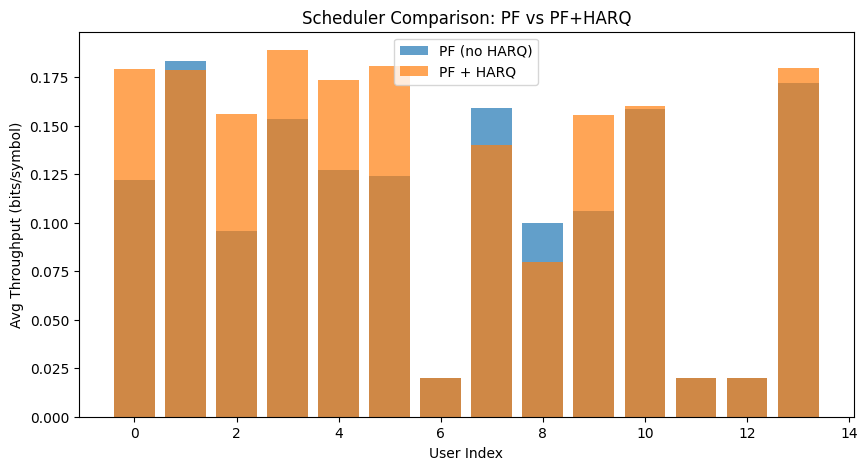

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example BLER curve (replace with your measured LDPC/Polar data)
snr_points = np.array([0, 2, 4, 6, 8, 10])
bler_qpsk = np.array([0.5, 0.3, 0.1, 0.01, 0.001, 0.0001])

def map_snr_to_bler(snr_db):
    return np.interp(snr_db, snr_points, bler_qpsk)

# HARQ model: Chase combining (2 transmissions max)
def harq_success_prob(snr_db):
    bler = map_snr_to_bler(snr_db)
    return 1 - bler**2  # success probability after up to 2 transmissions

# System parameters
num_users = np.random.randint(10, 21)  # 10–20 users
snrs = np.random.uniform(0, 10, num_users)  # random SNRs per user
spectral_eff = 2  # bits/symbol for QPSK
num_slots = 100   # scheduling slots

# --- PF Scheduler (no HARQ) ---
throughputs_pf = np.zeros(num_users)
past_avg_pf = np.ones(num_users) * 0.1

for t in range(num_slots):
    inst_thr = (1 - np.array([map_snr_to_bler(snr) for snr in snrs])) * spectral_eff
    pf_metric = inst_thr / past_avg_pf
    user = np.argmax(pf_metric)
    throughputs_pf[user] += inst_thr[user]
    past_avg_pf[user] = (past_avg_pf[user]*t + inst_thr[user])/(t+1)

avg_thr_pf = throughputs_pf / num_slots

# --- PF Scheduler with HARQ ---
throughputs_pf_harq = np.zeros(num_users)
past_avg_pf_harq = np.ones(num_users) * 0.1

for t in range(num_slots):
    inst_thr = harq_success_prob(snrs) * spectral_eff
    pf_metric = inst_thr / past_avg_pf_harq
    user = np.argmax(pf_metric)
    throughputs_pf_harq[user] += inst_thr[user]
    past_avg_pf_harq[user] = (past_avg_pf_harq[user]*t + inst_thr[user])/(t+1)

avg_thr_pf_harq = throughputs_pf_harq / num_slots

# Results
print("Number of Users:", num_users)
print("User SNRs (dB):", np.round(snrs,2))
print("PF Avg Throughputs:", np.round(avg_thr_pf,3))
print("PF+HARQ Avg Throughputs:", np.round(avg_thr_pf_harq,3))
print("Cell Avg Throughput (PF):", np.mean(avg_thr_pf))
print("Cell Avg Throughput (PF+HARQ):", np.mean(avg_thr_pf_harq))

# Plot comparison
plt.figure(figsize=(10,5))
plt.bar(range(num_users), avg_thr_pf, alpha=0.7, label='PF (no HARQ)')
plt.bar(range(num_users), avg_thr_pf_harq, alpha=0.7, label='PF + HARQ')
plt.xlabel("User Index")
plt.ylabel("Avg Throughput (bits/symbol)")
plt.title("Scheduler Comparison: PF vs PF+HARQ")
plt.legend()
plt.show()
